# <img src="https://i.imgur.com/1voq3gc.png" width=100 height=100, style="vertical-align:middle;margin:0px 12px"/> Assignment 3
---

<!-- Disclaim: Please note that the examples there are for demonstration purposes only to introduce basic tools and functions which might be helpful in future when one wish to start working with their own research project.  -->

## Environment Setup 
---

### Development Environment Setup
Make sure to read [Development Setup Guideline](https://moodle.oulu.fi/pluginfile.php/2761255/mod_resource/content/2/Development_setup_guideline.pdf) for development environment setup. 

This assignment consists of the following files:

- Main notebook: `Assignment_3.ipynb`
- Data: OAI_data.csv (assignment 2 included OAI data access and tasks related to that data, so you can have a look on assignment 2)

For those who use Google Colab, upload those files to your `Colab Notebooks` folder on `Google Drive`.

### Submission

- Rename the notebook with solutions from `Assignment_3.ipynb` --> `<First name>.<Last name>.Assignment_3.ipynb`
- For more details, reference to the [FAQs page](https://moodle.oulu.fi/mod/page/view.php?id=1788245)
- Note: Only submit the notebook with solutions in .ipynb format. Do NOT compress it.


### Any questions
- Reference to [FAQs page](https://moodle.oulu.fi/mod/page/view.php?id=1788245).
- Or post your questions to [Q&A forum](https://moodle.oulu.fi/mod/forum/view.php?id=1755240).

In the Kellgren and Lawrence (KL) system, OA severity is graded into 05 levels:

<img src="https://www.researchgate.net/publication/359459364/figure/fig2/AS:11431281179347951@1691186606793/Examples-of-knee-osteoarthritis-images-and-the-corresponding-classification-criteria_W640.jpg" width=700 style="vertical-align:middle;margin:0px 12px"/>

`KL` grades are acquired during the follow-up visits. Two knees of each participant was graded individually, thus there exists the `SIDE` column to differentiate them. Refer to `Assignment_2.ipynb` for more detailed explanation of OA and Kellgren and Lawrence (KL) grades if needed.

In [25]:
def visualize_histograms(data_group_1, data_group_2, x_label, y_label, title):    
      # Figure size 
    plt.figure(figsize=(6, 3))

In [46]:
#Import necessary libraries
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import random

# Load data (remember to save OAI_data.csv to same location where Assignment_3.ibynb is located). 
csv_path = Path("C:/Users/Hi/OneDrive - University of Oulu and Oamk/Documents/EBDS/Python for data statistics/Assignment 3/OAI_data.csv")
df_OAI = pd.read_csv(csv_path)

# # Function to visualize histograms
def visualize_histograms(data_group_1, data_group_2, x_label, y_label, title):    
      # Figure size 
      plt.figure(figsize=(6, 3))

#     # Shift bin edges for better visualization (There are 5 Kl grades and they range from 0 to 4)
      bins = np.arange(6) - 0.5
      plt.xticks(range(5))
      plt.xlim([-1, 5])
    
#     # Plot histogram
      plt.hist(data_group_1, bins=bins, alpha=0.8, color='tab:red', label="Data Distribution (Group 1)")
      plt.hist(data_group_2, bins=bins, alpha=0.8, color='tab:blue', label="Data Distribution (Group 2)")
    
#     # Set title, labels, legend and grid for better visualization 
      plt.title(title)
      plt.xlabel(x_label)
      plt.ylabel(y_label)
      plt.legend()
      plt.grid(True)

# # Function to visualize histograms with confidence intervals
def visualize_histogram_with_confidence_intervals(histogram_data, ci_lower, ci_upper, title):    
    # Figure size 
    plt.figure(figsize=(6, 3))

    # Plot histogram
    plt.hist(histogram_data, bins=50, alpha=0.6, color='c', label="Data Distribution")

    # Plot lower bound and upper bound
    plt.axvline(x=ci_lower, color='b', linestyle='-.', label="Lower Bound")
    plt.axvline(x=ci_upper, color='r', linestyle='-.', label="Upper Bound")
    plt.axvline(x=np.mean(histogram_data), color='black', linestyle='-.', label="Mean")

    # Set title, labels, legend and grid for better visualization 
    plt.title(f"KL Grade Differences with Confidence Intervals ({title})")
    plt.xlabel("Difference Between KL Grades")
    plt.ylabel("Counts")
    plt.legend()
    plt.grid(True) 

# Function to visualize one histogram
def visualize_histogram(bootstrap_theta, title):
    # Figure size 
    plt.figure(figsize=(6, 4))
    
    # Plot histogram
    plt.hist(bootstrap_theta, bins=50, alpha=0.8, color='tab:blue')
    plt.title(r'Histogram of the test statistics $\hat{\theta}$')
    plt.show()
    plt.close() 

In [140]:
import pandas as pd

# Assuming df_OAI is your original DataFrame
nan_count = df_OAI['KL'].isna().sum()
print(f"Number of NaN values in the 'KL' column: {nan_count}")

Number of NaN values in the 'KL' column: 555


---
# Part 2: Two-Sample Tests (13pts)

#### **Important Notes:**
- An `assert()` statement is provided in the code to verify that obtained result is right. It will raise error if wrong result was obtained.
- Only modify content under the *TODO: Write your code here sections*, do NOT modify any other sections.

---
### **Task 1: Extracting data and implementing bootstraping (4 pts)**
The aim of this task is to learn how to implement bootsraping.

---
### **Task 1.1 : Extracting Data for Group 1 and Group 2 (1 pt)**

Follow these steps to extract data for Group 1 and Group 2 from the loaded `df_OAI` dataframe:

1. **Group 1:** Filter `df_OAI` to include only rows where `'Age' >= 60` and `'Sex' == 'Female'`. Save the result as `group_1`.  
2. **Group 2:** Filter `df_OAI` to include only rows where `'Age' >= 60` and `'Sex' == 'Male'`. Save the result as `group_2`.  
3. **Keep Only KL Column:** For both `group_1` and `group_2`, drop all columns except `'KL'`.  
4. **Remove Missing Values:** Use `dropna()` to remove rows with NaN values in the `'KL'` column for both groups.  
5. **Convert to NumPy Arrays:** Convert both dataframes to NumPy arrays using `.to_numpy()`.  

After these steps, you should have:
- `group_1`: a NumPy array with shape `(n_samples_in_group_1,)`
- `group_2`: a NumPy array with shape `(n_samples_in_group_2,)`

(19745,)
(13391,)
Mean KL grade from group 1 (female, age >= 60): 1.2722208153963028
Mean KL grade from group 2 (male, age >= 60): 1.285340900604884
Task passed!


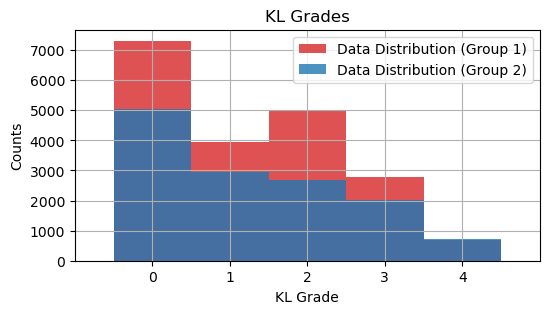

In [72]:
# ------------ TODO: Write your code here:  
group_1 = df_OAI[(df_OAI['Age'] >= 60) & (df_OAI['Sex'] == 'Female')]['KL'].dropna().to_numpy()
group_2 = df_OAI[(df_OAI['Age'] >= 60) & (df_OAI['Sex'] == 'Male')]['KL'].dropna().to_numpy()

# ------------ 

print(group_1.shape)
print(group_2.shape)

print(f'Mean KL grade from group 1 (female, age >= 60): {group_1.mean()}')
print(f'Mean KL grade from group 2 (male, age >= 60): {group_2.mean()}')

# Raise error if the wrong value was obtained; otherwise, print 'Task passed!'
assert group_1.shape == (19745,)
assert group_2.shape == (13391,)
assert np.round(group_1.mean(), 3) == np.round(1.2722208153963028, 3)
assert np.round(group_2.mean(), 3) == np.round(1.285340900604884, 3)
print('Task passed!')

# Visualizes the data distribution of the two groups if task was passed.
visualize_histograms(group_1, group_2, x_label = "KL Grade", y_label = "Counts", title = 'KL Grades')

---
### **Task 1.2: Implementing Bootstrap Sampling (Two Groups) (3 pts)**

In this task, you will implement a **bootstrap_sampling()** function to compare **Group 1** and **Group 2** using a selected test statistic (mean).

#### 🚀 **Steps to Complete the Task:**

1. **Initialize the Function:**
   - Define a function `bootstrap_sampling()` with the following parameters:
     - `group_1` and `group_2`: Input data arrays for each group.
     - `n_bootstraps`: Number of bootstrap resampling iterations.

2. **Resample Data with Replacement:**
   - For each group, use `np.random.choice()` to randomly select samples **with replacement**:
     - Sample **`n` elements**, where `n` is the size of the respective group (`len(group_1)` or `len(group_2)`).
     - Store the resampled data from group 1 to `resampled_group_1`. Store the resampled data from group 2 to `resampled_group_2`. 

3. **Compute the Test Statistic:**
   - Compute test statistics (mean) over `resampled_group_1` variable and save result to `result_from_resampled_group_1`. 
   - Compute test statistics (mean) over `resampled_group_2` variable and save result to `result_from_resampled_group_2`. 
   - Create one tuple from `result_from_resampled_group_1` and `result_from_resampled_group_2`. 
   - Append created tuple to list named as `result`.

4. **Aggregate and Compare Results:**
   - Repeat steps 2 and 3 for `n_bootstraps` iterations.   
   - After all iterations, apply command `np.array()` to `result` list to have a Numpy array of size `(n_bootstraps, 2)`
   - Then calculate the **difference between Group 1 and Group 2** for each pair of computed statistics:     
   `Difference` = `Result from Group 1` - `Result from Group 2`
   - Save computed differences to `computed_test_statistic`. That variable should contain `n_bootstraps` differences.

#### ⚡ **Note:**
- **Reproducibility:** Use `np.random.seed(42)` to ensure consistent results across runs.

The mean of bootstrap_theta is: -0.013225729948411208
Task passed!


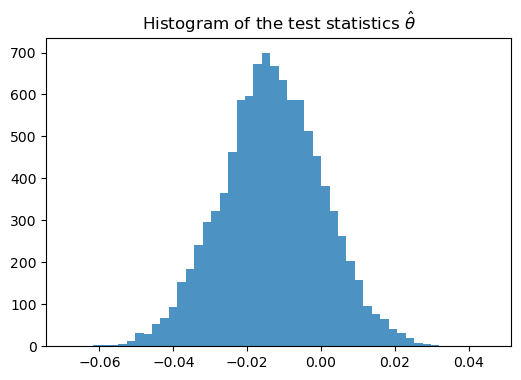

In [98]:
def bootstrap_sampling(group_1: np.ndarray, group_2: np.ndarray, n_bootstraps: int) -> np.ndarray:
    
    # Set seed to have reproducible results    
    np.random.seed(42)      

    # Initialize 'result' list to store n_bootstraps means computed from group 1,
    # and n_bootstraps means computed from group 2      
    result = [] 
    
    # ------------ TODO: Write your code here: 
    # Hint 1: For loop to compute test statistics n_bootstraps times (perform steps 2 and 3 below the for loop)
    for _ in range(n_bootstraps):
        # I will resample group_1 and group_2 with replacement
        boot_sample_1 = np.random.choice(group_1, size = len(group_1), replace = True)
        boot_sample_2 = np.random.choice(group_2, size = len(group_2), replace = True)
        
        # Now compute the mean (test statistics) for each bootstraps
        mean_1 = np.mean(boot_sample_1)
        mean_2 = np.mean(boot_sample_2)
        
        #Now store the difference between means for this iteration
        result.append(mean_1 - mean_2)

    # Step 2: # Hint 2: Change 'result' list to array (perform this after for loop) 
    result = np.array(result)

    # Hint 3: Compute the difference between mean test statistics from group 1 and mean test statistics from group 2 (perform this after for loop
    computed_test_statistic = result
        
    # ------------     

    # Raise error if the shape of the output is wrong 
    assert computed_test_statistic.shape == (n_bootstraps,) 

    return computed_test_statistic 


# Data will be resampled n_bootstraps times (n_bootstraps = 10 000)
n_bootstraps = 10000  

# Result (test_stats) will contain n_bootstraps elements
test_stats = bootstrap_sampling(group_1 = group_1, group_2 = group_2, n_bootstraps = n_bootstraps)
bootstrap_theta = test_stats 
print(f'The mean of bootstrap_theta is: {bootstrap_theta.mean()}')  

# Raise error if wrong value was obtained, otherwise print 'Task passed!'
assert np.round(np.mean(bootstrap_theta), 3) == np.round(-0.013225729948411208, 3)
print('Task passed!')

# Visualize histogram if task was passed
visualize_histogram(bootstrap_theta = bootstrap_theta, title = r'Histogram of the test statistics $\hat{\theta}$')

---
### **Task 2: Bootstrapping for 95% Confidence Interval (CI) Estimation and Visualization (6 pts)**

In **Task 1**, you implemented bootstrapping to compare **Group 1** and **Group 2** based on the difference in their KL grades (i.e., the difference between their mean KL grades).

In this task, you will:
- **Estimate the 95% Confidence Interval (CI)** for the obtained difference using the results from bootstrapping.

This will help you assess the statistical significance and variability of the observed difference between the two groups.


---
### **Task 2.1: Implementing Naïve 95% Confidence Intervals (CI) via Percentiles (3 pts)**

Your task is to create a **naive_ci_via_percentiles()** function that computes the **95% Confidence Interval (CI)** for the obtained metric using the **percentile method**. Statistically, this means that there is a **95% probability** that the computed CI will contain the true value.

The naïve 95% CI can be calculated using the following formulas from **Lecture 6**:

$$
\begin{align*}
   \text{Lower Bound} &= \hat{\theta}^{*}_{\alpha/2} \\
   \text{Upper Bound} &= \hat{\theta}^{*}_{(1 - \alpha/2)}   
\end{align*}
$$

Where:  
- **$\hat{\theta}^{*}$** represents the bootstrap distribution of the test statistic (refers for `bootstrap_theta` variable).  
- **$\alpha$** (`alpha_value`) is the significance level, set to **5%** for a 95% CI.  
- **$\hat{\theta}^{*}_{(1 - \alpha/2)}$** corresponds to the **97.5th percentile** of the bootstrap distribution.  
- **$\hat{\theta}^{*}_{\alpha/2}$** corresponds to the **2.5th percentile** of the bootstrap distribution.

### 🚀 **Steps to Complete the Task:**

1. **Compute $\alpha/2$** using the `alpha` variable and save the result in the `lower_percentile` variable.  
2. **Compute $1 - \alpha/2$** using the `alpha` variable and save the result in the `upper_percentile` variable.  
3. **Calculate the Lower Bound:**  
   - Obtain the **2.5th percentile** from the bootstrap distribution **$\hat{\theta}^{*}$** (`bootstrap_theta`) using the `np.percentile()` function with `lower_percentile`.  
4. **Calculate the Upper Bound:**  
   - Obtain the **97.5th percentile** from the bootstrap distribution **$\hat{\theta}^{*}$** (`bootstrap_theta`) using the `np.percentile()` function with `upper_percentile`.

By the end of this task, you will have a function that estimates the 95% CI for the bootstrapped test statistics, providing insights into the variability and reliability of your results.


The ci_lower is: -0.0402515137792531
The ci_upper is: 0.013691006263698258
Task passed!


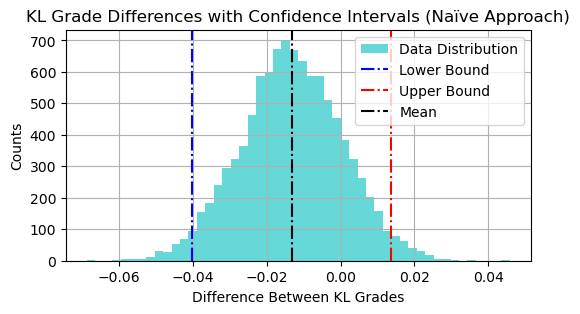

In [107]:
def naive_ci_via_percentiles(bootstrap_theta: np.ndarray, alpha_value: float) -> tuple:

    # ------------ TODO: Write your code here: 
    # Step 1 Compute the lower percentile (alpha/2)
    lower_percentile = alpha_value/2*100 # I am converting percentage to np.percentile here 
    
    # Step 2: Compute the upper percentile (1 - alpha/2)
    upper_percentile = (1 - alpha_value / 2) * 100  # Convert to percentage for np.percentile

    # Step 3: Calculate the Lower Bound (2.5th percentile)
    lower_bound = np.percentile(bootstrap_theta, lower_percentile)
    
    # Step 4: Calculate the Upper Bound (97.5th percentile)
    upper_bound = np.percentile(bootstrap_theta, upper_percentile)
        
    # ------------ 

    return lower_bound, upper_bound


alpha = 0.05
ci_lower, ci_upper = naive_ci_via_percentiles(bootstrap_theta=bootstrap_theta, alpha_value=alpha)

print(f'The ci_lower is: {ci_lower}')
print(f'The ci_upper is: {ci_upper}')

# Raise error if wrong value was obtained, otherwise print 'Task passed!'
assert np.round(ci_lower, 3) == np.round(-0.0402515137792531, 3)
assert np.round(ci_upper, 3) == np.round(0.013691006263698258, 3)
print('Task passed!')

# Plot histogram with computed confidence intervals if task was passed  
visualize_histogram_with_confidence_intervals(histogram_data = bootstrap_theta, ci_lower = ci_lower, 
                                              ci_upper = ci_upper, title = 'Naïve Approach')

---
### **Task 2.2: Implementing a More Accurate 95% Confidence Interval (CI) Estimation (3 pts)**

In this task, you are required to create a **normal_dist_ci()** function that computes a **95% Confidence Interval (CI)** for the obtained metric using a more accurate estimate than the method used in **Task 2.1**. You will also implement a **compute_theta_hat()** function to define variable which will be fed to **normal_dist_ci()** function.   

### Key Points:
- This method should be applied **only to normal distributions**.
- Statistically, there will still be **95%** confidence that the CI will contain the true value.
- The more accurate 95% CI can be computed using the following formulas from **Lecture 6**:

$$
\begin{align*}
  \text{Lower Bound} &= 2\hat{\theta} - \theta^{*}_{(1 - \alpha/2)} \\
   \text{Upper Bound} &= 2\hat{\theta} - \theta^{*}_{\alpha/2} 
\end{align*}
$$

Where:
- **$\hat{\theta}$** (`theta_hat`) refers to the observed metric.  
  - The observed metric is computed similarly to the test statistic in bootstrapping, but **without resampling**, meaning there will be a **single value** instead of a bootstrap distribution.    
- **$\theta^{*}$** represents the bootstrap distribution of the test statistic (refers for `bootstrap_theta` variable).  
- **$\alpha$** (`alpha_value`) refers to the significance level, which is **5%** for a 95% CI.


### 🚀 **Steps to Complete the Task:**

1. **Compute the observed metric $\hat{\theta}$ (`theta_hat`)** in function `compute_theta_hat()` 
   - Compute the mean of `group_1` and subtract the mean of `group_2`. Note: the order has to be correct.
   - This will give you the observed metric **$\hat{\theta}$** (`theta_hat`).  

2. **Implement the `normal_dist_ci()` function:**  
   This function computes the more accurate **95% Confidence Interval** using the following steps:
   
   - **Step 1:** Compute $\alpha/2$ using the `alpha` variable and save the result in `lower_percentile`.
   - **Step 2:** Compute $1 - \alpha/2$ using the `alpha` variable and save the result in `upper_percentile`.
   - **Step 3:** Calculate the Lower Bound:  
     - Obtain the **2.5th percentile** from the bootstrap distribution **$\theta^{*}$** using the `np.percentile()` function with `lower_percentile`.  
     - Compute the lower bound using the formula:  
       $$\text{lower bound} = 2  \hat{\theta} - \theta^{*}_{\alpha/2}$$  
     - Save the result in the `lower_bound` variable.
   - **Step 4:** Calculate the Upper Bound:  
     - Obtain the **97.5th percentile** from the bootstrap distribution **$\theta^{*}$** using the `np.percentile()` function with `upper_percentile`.  
     - Compute the upper bound using the formula:  
       $$\text{upper bound} = 2 \hat{\theta} - \theta^{*}_{(1 - \alpha/2)}$$  
     - Save the result in the `upper_bound` variable.

By the end of this task, you will have computed a more accurate 95% CI for the observed metric.


The theta_hat is: -0.0131200852085811
better_ci_lower: -0.03993117668086046
better_ci_upper: 0.014011343362090901
Task passed!


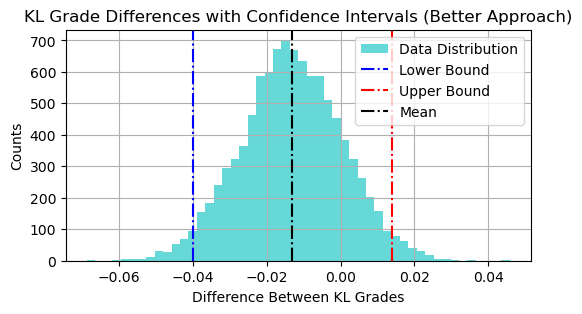

In [129]:
def compute_theta_hat(group_1: np.ndarray, group_2: np.ndarray) -> float:

    # ------------ TODO: Write your code here: 
    theta_hat_value = np.mean(group_1) - np.mean(group_2)  # Observed difference in means
    # ------------ 
    
    return theta_hat_value

def normal_dist_ci(theta_hat: float, bootstrap_theta: np.ndarray, alpha_value: float) -> tuple:

    # ------------ TODO: Write your code here:  
    # Step 1: Compute alpha/2 and save as lower_percentile
    lower_percentile = alpha_value / 2 * 100  # Convert to percentage for np.percentile

    # Step 2: Compute 1 - alpha/2 and save as upper_percentile
    upper_percentile = (1 - alpha_value / 2) * 100  # Convert to percentage for np.percentile

   # Compute percentiles from bootstrap_theta
    theta_star_lower = np.percentile(bootstrap_theta, lower_percentile)  # 2.5th percentile
    theta_star_upper = np.percentile(bootstrap_theta, upper_percentile)  # 97.5th percentile

    # Step 3: Calculate the Lower Bound
    # Formula: 2 * theta_hat - theta^*_{(1 - alpha/2)} (97.5th percentile)
    lower_bound = 2 * theta_hat - theta_star_upper

    # Step 4: Calculate the Upper Bound
    # Formula: 2 * theta_hat - theta^*_{alpha/2} (2.5th percentile)
    upper_bound = 2 * theta_hat - theta_star_lower

    # ------------
    
    return lower_bound, upper_bound

alpha = 0.05
theta_hat = compute_theta_hat(group_1, group_2) 
better_ci_lower, better_ci_upper = normal_dist_ci(theta_hat = theta_hat, bootstrap_theta = bootstrap_theta, alpha_value = alpha)

print(f'The theta_hat is: {theta_hat}')
print(f'better_ci_lower: {better_ci_lower}')
print(f'better_ci_upper: {better_ci_upper}')

# Raise error if wrong value was obtained, otherwise print 'Task passed!'
assert np.round(theta_hat, 3) == np.round(-0.0131200852085811, 3)
assert np.round(better_ci_lower, 3) == np.round(-0.03993117668086046, 3)
assert np.round(better_ci_upper, 3) == np.round(0.014011343362090901, 3)   
print('Task passed!')

# Plot histogram with computed confidence intervals if task was passed 
visualize_histogram_with_confidence_intervals(histogram_data = bootstrap_theta, ci_lower = better_ci_lower, 
                                              ci_upper = better_ci_upper, title = "Better Approach")

---
### **Task 3: Bootstrapping to Perform Two-Sample Test for KL Grade Comparison by Gender in a Specific Age Group (3 pts)**

In this task, you will implement p-value computation using bootstrapping methods to perform hypothesis testing. The objective is to test whether there is differenece in KL grade between men and women in a specific age group (age >= 60).

#### Overview
Hypothesis testing helps determine whether there is a statistically significant difference between the KL grades of men and women in the specified age group. You will compute p-value to assess this difference. 

#### Hypothesis Testing

**Two-Sided Test (General Difference)**
   - **Null Hypothesis (H₀):** There is no difference between the groups.
     - $H_0: \mu_1 = \mu_2$
   - **Alternative Hypothesis (H₁):** There is a difference between the groups.
     - $H_1: \mu_1 \neq \mu_2$

   A two-sided p-value tests whether there is any significant difference in KL grades between the two groups (men and women).

#### ⚡ **Note:**
- As discussed in Lecture 7, p-value should not be interpreted in isolation, as factors like the number of samples analyzed can affect the results.    





---
#### **Task 3.1: Computing two-sided p-value (2 pts)**
In this task you will implement a **compute_p_value()** function which computes two-sided p-value for studied metric. Two-sided p-value can be computed by using formula from **lecture 7**: <br>
$p = 2 \text{ min } \Biggl\{  
                       \underbrace{\mathbb{P}(Z \leq \hat{z} \mid H_{0}) }_{ F_{Z}(\hat{z}) }, 
                       \underbrace{\mathbb{P}(Z \geq \hat{z} \mid H_{0}) }_{ 1 - F_{Z}(\hat{z}) + \mathbb{P}(\hat{z}=0) } 
                     \Biggl\}$         

#### 🚀 **Steps to Complete the Task:** 
1. Define null distribution by usin formula: *null distribution* = *bootsrap test statistic* (`bootstrap_theta`) - *observed test statistic* (`theta_hat`)
2. Count how many cases ($m$) there are in $\lVert \text{null distribution} \lVert$ which have greater value than $\lVert \text{observed test statistic} \lVert$
4. Compute the left cumulative density function $F_{Z}(\hat{z})$ by computing: $(m+1) / (\text{n\_bootstraps} + 1)$
5. Compute two-sided p-value by computing: $2 * \min(F_{Z}(\hat{z}), 1 -F_{Z}(\hat{z}))$.

#### ⚡ **Note:**
- $\lVert \lVert$  refers for absolute value which can be obtained by np.abs() command 

In [136]:
def compute_p_value(test_stats: np.ndarray, observed: np.ndarray, n_bootstraps: int) -> float:

    # ------------ TODO: Write your code here:
    
    # Step 1: Define null distribution
    null_distribution = test_stats - observed  # Center around zero under H_0

    # Step 2: Count cases (m) where |null_distribution| >= |observed|
    m = np.sum(np.abs(null_distribution) >= np.abs(observed))

    # Step 3: Compute F_Z(z_hat) - left cumulative probability
    f_z = (m + 1) / (n_bootstraps + 1)

    # Step 4: Compute two-sided p-value
    p_two_sided = 2 * min(f_z, 1 - f_z)
  
    # ------------

    return p_two_sided

#Compute two-sided p-value
p_val_two_sided = compute_p_value(test_stats=bootstrap_theta, observed=theta_hat, n_bootstraps=n_bootstraps)

print(f'Two-sided p-value: {p_val_two_sided}') 


Two-sided p-value: 0.6719328067193281


---
#### **Task 3.2: Judging if null hypothesis can be rejected (1pt)**

State your conclusion given the computed p-value.

In [ ]:
# # TODO: Write your answer here
# Based on a two-sided p-value of 0.6719328067193281 and a significance level of 0.05, we fail to reject the null hypothesis.

# Also, 
# Magnitude: The difference in means (-0.01312) is small relative to the KL scale (0 to 4). 
# For example:
# Females: 1.272 (mild osteoarthritis, between grades 1 and 2).
# Males: 1.285 (also mild, very close to females).
# A difference of 0.013 is practically negligible in this context (less than 1% of the scale range).
                                                                 
# Statistical Significance: 
# The p-value of 0.672 suggests that in 67.2% of bootstrap samples under Null hypothesis, we would see a difference at least as extreme as -0.01312. 
# This is far from significant, reinforcing that the data doesn’t support a real difference.
    
# Power: With large sample sizes (19,745 females + 13,391 males = 33,136), the test has high power to detect even small differences. 
# The high p-value, despite this power, indicates the true difference is likely very close to zero.